# **Fine-Tuning Object Detection**
# **Using the Penn-Fudan Pedestrian Dataset**

# Import Libraries

In [ ]:
import os
import urllib.request
import zipfile
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Downloading dataset

In [ ]:
url = 'https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip'
zip_path = 'PennFudanPed.zip'

if not os.path.exists('PennFudanPed'):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')
    os.remove(zip_path)
    print("Download complete!")
else:
    print("Dataset already exists.")

Download complete!


# Explore the data

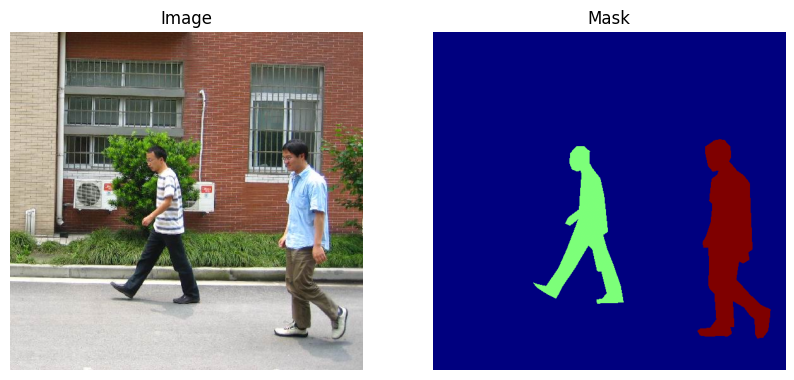

Mask values: [0 1 2]


In [ ]:
import matplotlib.pyplot as plt

img = Image.open("PennFudanPed/PNGImages/FudanPed00001.png")
mask = Image.open("PennFudanPed/PedMasks/FudanPed00001_mask.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img)
axes[0].set_title("Image")

axes[1].imshow(np.array(mask), cmap="jet")
axes[1].set_title("Mask")

for ax in axes:
    ax.axis("off")

plt.show()

print("Mask values:", np.unique(np.array(mask)))

# Build dataset class

In [ ]:
from torch.utils.data import Dataset
from torchvision import transforms

class PennFudanDataset(Dataset):
    def __init__(self, root):
        self.root = root
        self.imgs = sorted(os.listdir(os.path.join(root, "PNGImages")))
        self.masks = sorted(os.listdir(os.path.join(root, "PedMasks")))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = np.array(Image.open(mask_path))

        obj_ids = np.unique(mask)
        obj_ids = obj_ids[obj_ids != 0]

        boxes = []
        for obj_id in obj_ids:
            pos = np.where(mask == obj_id)
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])

            if xmax > xmin and ymax > ymin:
                boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.ones((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        image = transforms.ToTensor()(image)

        return image, target

# Dataloader

In [ ]:
from torch.utils.data import DataLoader

dataset = PennFudanDataset("PennFudanPed")

torch.manual_seed(42)

train_size = 140
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, test_size]
)

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 140
Test: 30


# Build a model

In [ ]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model(num_classes):
    model = fasterrcnn_resnet50_fpn(pretrained=True)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

model = get_model(2)
model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 164MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

# Configure the Optimizer

In [ ]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# Training

In [ ]:
NUM_EPOCHS = 2

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{"boxes": t["boxes"].to(device),
                    "labels": t["labels"].to(device)} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

print("Training complete!")

Epoch 1, Loss: 12.0643
Epoch 2, Loss: 4.9469
Training complete!


# Save and Load the model

In [ ]:
torch.save(model.state_dict(), "pedestrian_detector.pth")

def load_model(path):
    model = get_model(2)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

model = load_model("pedestrian_detector.pth")

# Visualization

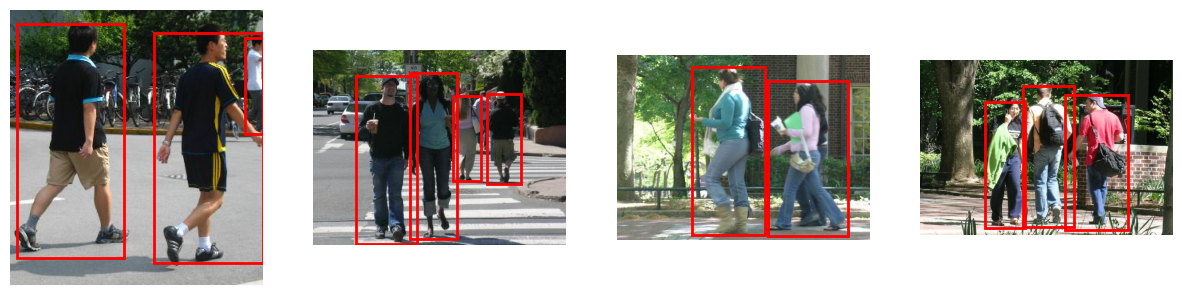

In [ ]:
import matplotlib.patches as patches

def test_and_visualize(model, dataset, num_images=4, threshold=0.5):
    model.eval()

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i in range(num_images):
        img_tensor, _ = dataset[i]

        with torch.no_grad():
            pred = model([img_tensor.to(device)])[0]

        mask = pred['scores'] > threshold
        boxes = pred['boxes'][mask].cpu()

        img_np = img_tensor.permute(1, 2, 0).numpy()
        ax = axes[i]

        ax.imshow(img_np)

        for box in boxes:
            x1, y1, x2, y2 = box
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

        ax.axis("off")

    plt.show()

test_and_visualize(model, test_dataset)

# Testing

In [ ]:
def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    correct, predicted, actual = 0, 0, 0

    for images, targets in loader:
        images = [img.to(device) for img in images]

        with torch.no_grad():
            preds = model(images)

        for pred, target in zip(preds, targets):
            pred_boxes = pred['boxes'][pred['scores'] > threshold].cpu()
            gt_boxes = target['boxes']

            predicted += len(pred_boxes)
            actual += len(gt_boxes)

            for pb in pred_boxes:
                for gb in gt_boxes:
                    x1 = max(pb[0], gb[0])
                    y1 = max(pb[1], gb[1])
                    x2 = min(pb[2], gb[2])
                    y2 = min(pb[3], gb[3])

                    inter = max(0, x2-x1) * max(0, y2-y1)
                    union = (pb[2]-pb[0])*(pb[3]-pb[1]) + (gb[2]-gb[0])*(gb[3]-gb[1]) - inter

                    if union > 0 and inter/union > 0.5:
                        correct += 1
                        break

    precision = correct / max(predicted, 1)
    recall = correct / max(actual, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-6)

    print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}")

evaluate_model(model, test_loader)

Precision: 0.82, Recall: 1.00, F1: 0.90
